In [2257]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ta

In [2258]:
ticker='BTC-USD'
date="2025-05-30"
end="2025-09-18"
df=yf.download(ticker,start=date,end=end)
df.columns=[i[0] for i in df.columns]
df['Date']=df.index
df['Pct_Change']=df['Open'].pct_change()
df.dropna(inplace=True)
df['adj']=((df['Close']+df['Open'])/2)
df

C:\Users\user\AppData\Local\Temp\ipykernel_5324\2942307901.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df=yf.download(ticker,start=date,end=end)
[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume,Date,Pct_Change,adj
Date,,,,,,,,
2025-05-31,104638.093750,104927.101562,103136.117188,103994.718750,38997843858,2025-05-31,-0.015632,104316.406250
2025-06-01,105652.101562,105884.546875,103826.953125,104637.296875,37397056873,2025-06-01,0.006179,105144.699219
2025-06-02,105881.531250,105958.312500,103727.546875,105649.812500,45819706290,2025-06-02,0.009676,105765.671875
2025-06-03,105432.468750,106813.578125,104920.843750,105888.476562,46196508367,2025-06-03,0.002259,105660.472656
2025-06-04,104731.984375,105997.695312,104232.703125,105434.367188,44544857105,2025-06-04,-0.004289,105083.175781
...,...,...,...,...,...,...,...,...
2025-09-03,111723.210938,112600.226562,110582.960938,111190.695312,61119643565,2025-09-03,0.017828,111456.953125
2025-09-04,110723.601562,112208.328125,109347.226562,111718.148438,60131132901,2025-09-04,0.004744,111220.875000
2025-09-05,110650.984375,113357.492188,110233.398438,110723.015625,60241647677,2025-09-05,-0.008908,110687.000000


In [2259]:
df['Open'].tail(2).tolist()

[110650.5703125, 110214.8359375]

In [2260]:
last_date = df.index[-1]
new_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=1,freq="24H")
new_dates
new_rows = pd.DataFrame({
    "Open": [None]*1,
    "High": [None]*1,
    "Low": [None]*1,
    "Close": [None]*1,
    "Volume":[None]*1,
    "Date":new_dates})
# Append
df = pd.concat([df, new_rows], ignore_index=True)
df = df.set_index("Date")
df.loc[df.index[-1:], "Open"]=[df['Close'].tail(2).values[0]]*1
df

C:\Users\user\AppData\Local\Temp\ipykernel_5324\1638316305.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  new_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=1,freq="24H")
C:\Users\user\AppData\Local\Temp\ipykernel_5324\1638316305.py:12: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, new_rows], ignore_index=True)


,Close,High,Low,Open,Volume,Pct_Change,adj
Date,,,,,,,
2025-05-31,104638.093750,104927.101562,103136.117188,103994.718750,38997843858,-0.015632,104316.406250
2025-06-01,105652.101562,105884.546875,103826.953125,104637.296875,37397056873,0.006179,105144.699219
2025-06-02,105881.531250,105958.312500,103727.546875,105649.812500,45819706290,0.009676,105765.671875
2025-06-03,105432.468750,106813.578125,104920.843750,105888.476562,46196508367,0.002259,105660.472656
2025-06-04,104731.984375,105997.695312,104232.703125,105434.367188,44544857105,-0.004289,105083.175781
...,...,...,...,...,...,...,...
2025-09-04,110723.601562,112208.328125,109347.226562,111718.148438,60131132901,0.004744,111220.875000
2025-09-05,110650.984375,113357.492188,110233.398438,110723.015625,60241647677,-0.008908,110687.000000
2025-09-06,110224.695312,111275.015625,110024.085938,110650.570312,21500719036,-0.000654,110437.632812


In [2261]:
def flexible_rsi(series):
    delta = series.diff()
    up = delta.clip(lower=0)
    down = -delta.clip(upper=0)
    roll_up = up.rolling(window=10,center=True).mean()
    roll_down = down.rolling(window=10,center=True).mean()
    rs = roll_up / roll_down
    rsi = 100 - (100 / (1 + rs))
    rsi_scaled = (100 - (100 / (1 + rs)))/100
    return rsi_scaled
# Example usage
prices =df.Open
rsi_flex = flexible_rsi(prices)
df['Positions']=rsi_flex.shift(3)

In [2262]:
df['Pct_Change']=df['Open'].pct_change()
df.tail(10)

,Close,High,Low,Open,Volume,Pct_Change,adj,Positions
Date,,,,,,,,
2025-08-30,108808.070312,108929.351562,107444.445312,108409.406250,51486264208,-0.036793,108608.738281,0.370968
2025-08-31,108236.710938,109491.000000,108104.656250,108818.460938,47986191770,0.003773,108527.585938,0.394318
2025-09-01,109250.593750,109890.585938,107271.179688,108228.750000,66870372995,-0.005419,108739.671875,0.268657
2025-09-02,111200.585938,111748.015625,108454.031250,109243.070312,74776999491,0.009372,110221.828125,0.376166
2025-09-03,111723.210938,112600.226562,110582.960938,111190.695312,61119643565,0.017828,111456.953125,0.444062
2025-09-04,110723.601562,112208.328125,109347.226562,111718.148438,60131132901,0.004744,111220.875000,0.522679
2025-09-05,110650.984375,113357.492188,110233.398438,110723.015625,60241647677,-0.008908,110687.000000,0.450662
2025-09-06,110224.695312,111275.015625,110024.085938,110650.570312,21500719036,-0.000654,110437.632812,0.456201
2025-09-07,111294.640625,111373.484375,110214.835938,110214.835938,24536674304,-0.003938,110754.738281,0.443996


<Axes: xlabel='Date'>

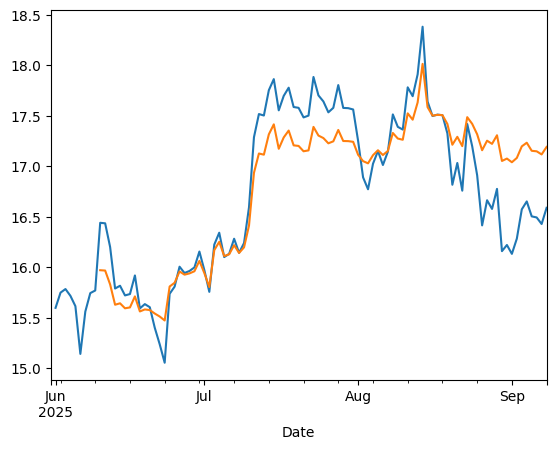

In [2263]:
(15.5*(1+df['Pct_Change']).cumprod()).plot()
(15.5*(1+(df['Positions'].shift(1)*df['Pct_Change'])).cumprod()).plot()

<Axes: xlabel='Date'>

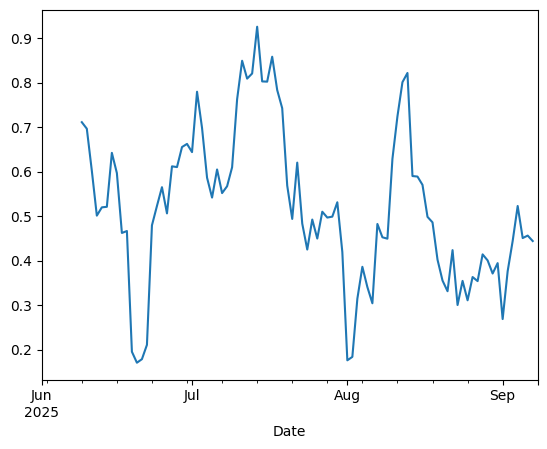

In [2256]:
df['Positions'].tail(100).plot()